In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent.resolve()))
from src.paths import *

In [ ]:
df = pd.read_excel(VALIDATION_SAMPLE)

## Tecnologies

In [10]:
import re
import pandas as pd

def encontrar_linguagem_robusta(tags_texto, linguagens_alvo):
    """
    Verifica se alguma linguagem alvo está presente na string de tags,
    usando uma regex robusta para lidar com caracteres especiais (+, #).
    """
    if pd.isna(tags_texto) or not tags_texto.strip():
        return 'N/A'

    tags_texto_lower = tags_texto.lower()

    for lang in linguagens_alvo:
        lang_lower = lang.lower()
        lang_escaped = re.escape(lang_lower)
        
        regex_busca = r'(^|,\s*)' + lang_escaped + r'(\s*,|$)'
    
        if re.search(regex_busca, tags_texto_lower):
            return lang
            
    return 'N/A'

In [11]:
LANGUAGES = ['Python', 'JavaScript', 'Java', 'PHP', 'C++', 'C#', 'C', 'Go', 'Perl', 'Ruby', 'Delphi']
LOWERCASE_LANGUAGES = [lang.lower() for lang in LANGUAGES]

df['language'] = df['technologies'].str.lower().apply(
    lambda x: encontrar_linguagem_robusta(x, LANGUAGES)
)

In [12]:
df['language'].value_counts() / df.shape[0] * 100

language
N/A           56.856187
Java          14.046823
C#            11.036789
JavaScript     4.682274
PHP            4.682274
Python         3.678930
C++            2.341137
C              1.003344
Go             0.668896
Perl           0.334448
Delphi         0.334448
Ruby           0.334448
Name: count, dtype: float64

<Axes: ylabel='language'>

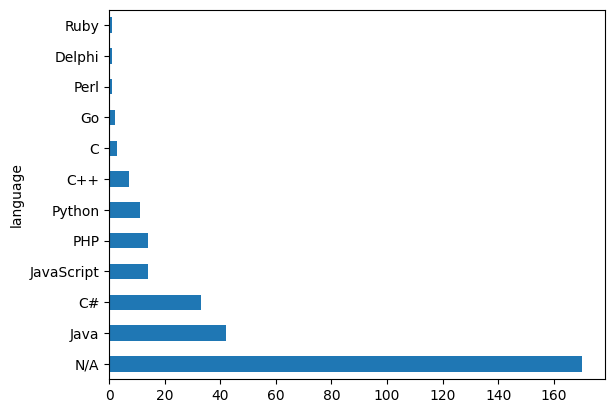

In [13]:
df['language'].value_counts().plot.barh()

In [14]:
def remove_languages_from_technologies(tech_string, languages_to_remove):
    """
    Remove as linguagens especificadas da string de tecnologias.
    """
    if pd.isna(tech_string) or not tech_string.strip():
        return 'N/A'
    
    tech_list = [tech.strip() for tech in tech_string.split(',')]
    filtered_list = [tech for tech in tech_list if tech.lower() not in [lang.lower() for lang in languages_to_remove]]
    
    # Join back
    return ', '.join(filtered_list) if filtered_list else 'N/A'

# Remove languages from technologies column
df['technologies_clean'] = df['technologies'].apply(lambda x: remove_languages_from_technologies(x, LANGUAGES))

In [15]:
exploded = (
    df['technologies_clean']
        .str.split(',')
        .explode()
        .str.strip()
        .str.replace('\xa0', '', regex=False)
        .str.lower()
        .replace('', pd.NA)
        .dropna()
)

In [16]:
contagem_palavras_clean = exploded.value_counts()
contagem_palavras_clean.head(10)

technologies_clean
aes        73
rsa        43
n/a        24
openssl    19
sha        16
md5        13
hmac       12
.net       12
hash       11
base64     10
Name: count, dtype: int64

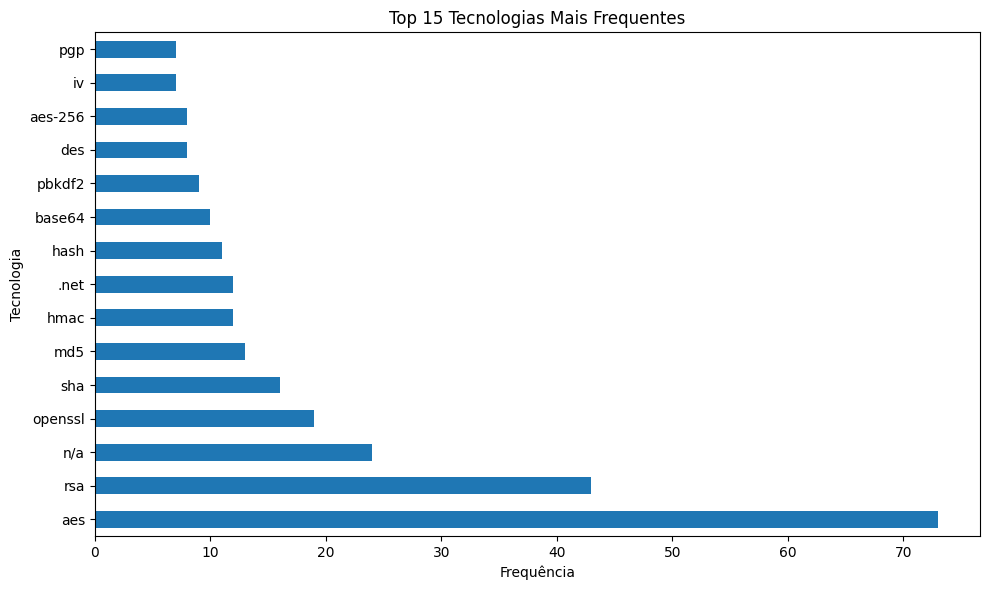

In [17]:
contagem_palavras_clean.head(15).plot.barh(figsize=(10, 6))
plt.title('Top 15 Tecnologias Mais Frequentes')
plt.xlabel('Frequência')
plt.ylabel('Tecnologia')
plt.tight_layout()
plt.show()

In [18]:
pd.set_option('display.max_rows', None)

In [19]:
contagem_palavras_clean / df.shape[0] * 100

technologies_clean
aes                           24.414716
rsa                           14.381271
n/a                            8.026756
openssl                        6.354515
sha                            5.351171
md5                            4.347826
hmac                           4.013378
.net                           4.013378
hash                           3.678930
base64                         3.344482
pbkdf2                         3.010033
des                            2.675585
aes-256                        2.675585
iv                             2.341137
pgp                            2.341137
tls                            2.006689
encryption                     2.006689
ssl                            2.006689
truecrypt                      2.006689
cryptojs                       1.672241
mysql                          1.672241
sql server                     1.672241
aes-128                        1.672241
cbc                            1.337793
xor                  

In [ ]:
df = pd.read_csv(r'C:\dev\social-media-dev-crawler\notebooks\classified_posts.csv')
df = df[df['type'] == 'question']

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Converter creation_date para datetime se necessário
df['creation_date'] = pd.to_datetime(df['creation_date'], errors='coerce')

# Extrair o ano
df['year'] = df['creation_date'].dt.year

# Agrupar por ano e tópico, contar ocorrências
topic_by_year = df.groupby(['year', 'topic']).size().reset_index(name='count')

# Calcular total de posts por ano
total_by_year = df.groupby('year').size().reset_index(name='total')

# Merge para calcular porcentagem
topic_by_year = topic_by_year.merge(total_by_year, on='year')
topic_by_year['percentage'] = (topic_by_year['count'] / topic_by_year['total']) * 100

# Obter todos os tópicos únicos
all_topics = sorted(df['topic'].unique())
n_topics = len(all_topics)

print(f"Total de tópicos: {n_topics}")

# Criar figura com subplots menores
fig, axes = plt.subplots(n_topics, 1, figsize=(9, 1.5 * n_topics), sharex=True)

# Garantir que axes seja sempre uma lista
if n_topics == 1:
    axes = [axes]

# Definir cores para cada tópico
colors = plt.cm.tab10(range(10))

# Criar um gráfico para cada tópico
for idx, topic in enumerate(all_topics):
    ax = axes[idx]
    
    # Criar eixo secundário para porcentagem
    ax2 = ax.twinx()
    
    # Filtrar dados do tópico
    topic_data = topic_by_year[topic_by_year['topic'] == topic].sort_values('year')
    
    if not topic_data.empty:
        color = colors[idx % 10]
        
        # Plotar contagem (linha sólida)
        line1 = ax.plot(topic_data['year'], topic_data['count'], 
                        marker='o', linewidth=2, markersize=4, 
                        color=color, label='Contagem (eixo esq.)',
                        linestyle='-', alpha=0.8)
        
        # Plotar porcentagem (linha tracejada)
        line2 = ax2.plot(topic_data['year'], topic_data['percentage'], 
                         marker='s', linewidth=2, markersize=3,
                         color=color, label='Porcentagem (eixo dir.)',
                         linestyle='--', alpha=0.6)
    
    # Configurar eixo esquerdo (contagem)
    ax.set_ylabel('Contagem', fontsize=8, fontweight='bold')
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    # Configurar eixo direito (porcentagem)
    ax2.set_ylabel('Porcentagem', fontsize=8, fontweight='bold', rotation=270, labelpad=12)
    ax2.tick_params(axis='y', labelsize=7)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
    
    # Título do tópico
    ax.set_title(f'{topic}', fontsize=9, fontweight='bold', loc='left', pad=3)
    
    # Remover label do eixo x de todos exceto o último
    if idx < n_topics - 1:
        ax.tick_params(labelbottom=False)
    
    # Adicionar legenda pequena
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, ['Contagem (esq.)', 'Porcentagem (dir.)'], 
              loc='upper right', fontsize=6, framealpha=0.9)

# Configurar o eixo x apenas no último subplot
axes[-1].set_xlabel('Ano', fontsize=9, fontweight='bold')
axes[-1].tick_params(axis='x', labelsize=8, rotation=45)

# Ajustar layout
plt.suptitle('Evolução dos Tópicos ao Longo do Tempo — Contagem e Porcentagem', 
             fontsize=12, fontweight='bold', y=0.998)
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()